In [3]:

import matplotlib.pyplot as plt
import pandas as pd
import math
import numpy as np

import btrack
from btrack.dataio import HDF5FileHandler
# from btrack import datasets

from skimage.io import imread
from skimage.util import montage
from skimage.transform import resize

from matplotlib.animation import FuncAnimation
from IPython.display import HTML



from helper import plot_track_montage


In [4]:
basepath = '/scratch/indikar_root/indikar1/shared_data/hybrid_imaging/segments'

segments_list = [
"01_hybrid_C4.npy",
"01_siPRRX1_B3.npy",
"02_control_D2.npy",
"02_mmMYOD1_D3.npy",
"test.npy",
"01_control_C2.npy",
"01_hybrid_C6.npy",
"01_siPRRX1_B4.npy",
"02_mmMYOD1_D4.npy",
"01_control_D2.npy",
"01_mmMYOD1_D3.npy",
"02_hybrid_C4.npy",
"02_siPRRX1_B3.npy",
"01_mmMYOD1_D4.npy",
"02_control_C2.npy",
"02_hybrid_C6.npy",
"02_siPRRX1_B4.npy"]

full_segments_list = [f'{basepath}/{i}' for i in segments_list]

full_segments_list

['/scratch/indikar_root/indikar1/shared_data/hybrid_imaging/segments/01_hybrid_C4.npy',
 '/scratch/indikar_root/indikar1/shared_data/hybrid_imaging/segments/01_siPRRX1_B3.npy',
 '/scratch/indikar_root/indikar1/shared_data/hybrid_imaging/segments/02_control_D2.npy',
 '/scratch/indikar_root/indikar1/shared_data/hybrid_imaging/segments/02_mmMYOD1_D3.npy',
 '/scratch/indikar_root/indikar1/shared_data/hybrid_imaging/segments/test.npy',
 '/scratch/indikar_root/indikar1/shared_data/hybrid_imaging/segments/01_control_C2.npy',
 '/scratch/indikar_root/indikar1/shared_data/hybrid_imaging/segments/01_hybrid_C6.npy',
 '/scratch/indikar_root/indikar1/shared_data/hybrid_imaging/segments/01_siPRRX1_B4.npy',
 '/scratch/indikar_root/indikar1/shared_data/hybrid_imaging/segments/02_mmMYOD1_D4.npy',
 '/scratch/indikar_root/indikar1/shared_data/hybrid_imaging/segments/01_control_D2.npy',
 '/scratch/indikar_root/indikar1/shared_data/hybrid_imaging/segments/01_mmMYOD1_D3.npy',
 '/scratch/indikar_root/indikar1

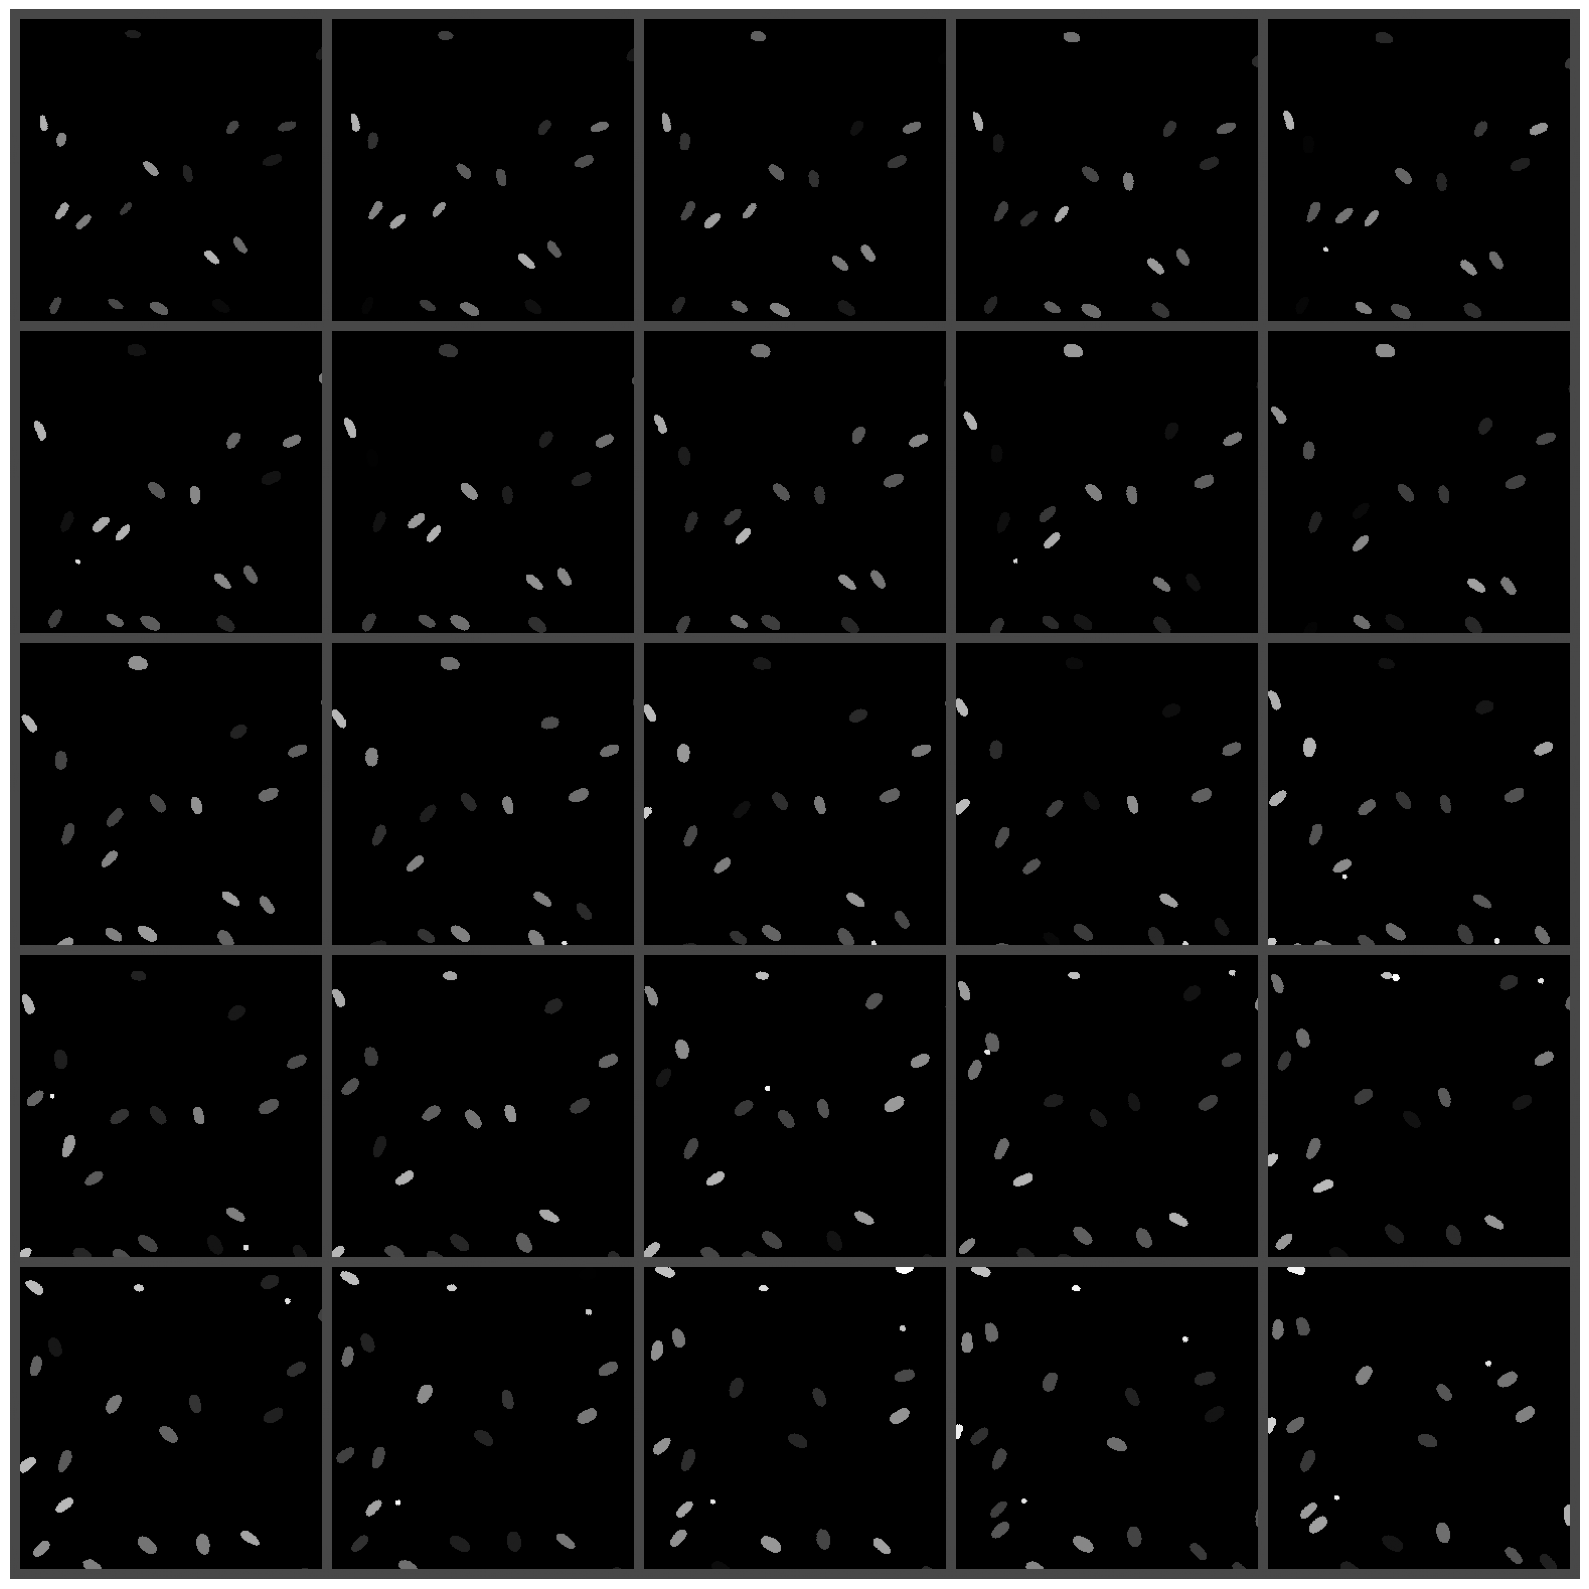

In [6]:

fname = segments_list[0]
filepath = full_segments_list[0]

segments_data = np.load(filepath)




# Full segmentation mask montage
seq = montage(
    segments_data[:25, :300, :300],
    grid_shape=(5, 5),
    padding_width=10,
    fill=255,
)


fig, ax = plt.subplots(figsize=(16, 16))
ax.imshow(seq, cmap="gray")
ax.axis("off")
plt.tight_layout()
plt.show()

In [9]:
h5_path = "/nfs/turbo/umms-indikar/Ram/projects/reprogramming/Image_analysis/tracking/tracks/01_hybrid_C4.npy.h5"
# h5_path = f"tracks/{fname}.h5"

with btrack.dataio.HDF5FileHandler(
    h5_path,
    "r",
    obj_type="obj_type_1",
) as reader:
    tracks = reader.tracks

print(f"Loaded {len(tracks)} tracks")


# Covnerting to dataframes for loading back

track_dfs = []

for track in tracks:
    track_df = pd.DataFrame(track.to_dict())
    track_dfs.append(track_df)

df = pd.concat(track_dfs, ignore_index=True)

df = df.sort_values(["ID", "t"]).reset_index(drop=True)

track_lengths = (
    df.groupby("ID")
    .size()
    .sort_values(ascending=False)
)

display(track_lengths.head(10))


# choose track number here
num = 1


track_id = track_lengths.index[2]


cell_crops, cell_trajectory = plot_track_montage(
    image_stack=segments_data,
    track_df=df,
    track_id=track_id,
    crop_size=200,
    ncols=5,
    show=False
)

[INFO][2026/07/15 01:36:59 PM] Opening HDF file: /nfs/turbo/umms-indikar/Ram/projects/reprogramming/Image_analysis/tracking/tracks/01_hybrid_C4.npy.h5...
[INFO][2026/07/15 01:36:59 PM] Loading tracks/obj_type_1
[INFO][2026/07/15 01:36:59 PM] Loading objects/obj_type_1 (64240, 5) (64240 filtered: None)
[INFO][2026/07/15 01:37:00 PM] Closing HDF file: /nfs/turbo/umms-indikar/Ram/projects/reprogramming/Image_analysis/tracking/tracks/01_hybrid_C4.npy.h5


Loaded 42617 tracks


ID
620    67
500    67
503    67
619    67
615    67
389    67
614    67
474    67
613    67
611    67
dtype: int64

In [10]:


times = cell_trajectory["t"].to_numpy()

vmin, vmax = np.percentile(cell_crops, [1, 99.5])

fig, ax = plt.subplots(figsize=(6, 6))

image_artist = ax.imshow(
    cell_crops[0],
    cmap="gray",
    vmin=vmin,
    vmax=vmax,
)

center = cell_crops.shape[1] / 2

center_artist = ax.scatter(
    center,
    center,
    marker="+",
    s=150,
    linewidths=2,
)

title_artist = ax.set_title(
    f"Track {track_id} | t = {times[0]}"
)

ax.axis("off")


def update(frame_index):
    image_artist.set_data(cell_crops[frame_index])
    title_artist.set_text(
        f"Track {track_id} | t = {times[frame_index]}"
    )

    return image_artist, center_artist, title_artist


animation = FuncAnimation(
    fig,
    update,
    frames=len(cell_crops),
    interval=300,   # milliseconds per frame
    blit=False,
    repeat=True,
)

plt.close(fig)

HTML(animation.to_jshtml())